In [1]:
#imports
import os
import sys
import random
from pathlib import Path
from shutil import copyfile
import multiprocessing as mp
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches

import matplotlib as mpl
from tqdm import tqdm


import numpy as  np
from astropy.io import fits
import pandas as pd

import pypeit
from pypeit.metadata import PypeItMetaData
from pypeit.spectrographs.util import load_spectrograph
from pypeit import spec2dobj, specobjs

from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter

# Custom imports
sys.path.append(str(Path.cwd() / 'reduction_pipeline'))
import rest_frame_correct as rfc
import spectra as sp

In [2]:
plt.rcParams.update({
    "figure.figsize": (8, 5),  # Default figure size
    "axes.titlesize": 16,      # Title font size
    "axes.labelsize": 14,      # Axis label font size
    "xtick.labelsize": 12,     # X-tick label font size
    "ytick.labelsize": 12,     # Y-tick label font size
    "legend.fontsize": 12,     # Legend font size
    "lines.linewidth": 2,      # Line width
    "grid.alpha": 0.5,         # Grid transparency
    "grid.linestyle": "--",    # Grid line style
    "axes.grid": True,         # Show grid
    "axes.facecolor": "#F6F5F3", # Axes background color
    "savefig.dpi": 300,        # Default DPI for saving figures
    "text.usetex": True,       # Use LaTeX for text rendering
    "font.family": "serif",    # Use serif fonts
})

cs = ["#335c67","#fff3b0","#e09f3e","#9e2a2b","#540b0e", "#b3b3cc"] # Color palette for plots

## **Load the Data**

In [3]:
source_df = pd.read_csv('M71_xmatch_sources.csv')


#apogee
allstar = pd.read_hdf('/geir_data/scr/nwolfish/DATA/apogee_dr17.h5', key = 'allstar')
allstar['APOGEE_ID'] = allstar['APOGEE_ID'].str.decode('utf-8') #decoding
allstar['FIELD'] = allstar['FIELD'].str.decode('utf-8') #decoding
allstar.drop(index=11215, inplace=True)
allstar.reset_index(drop=True, inplace=True)

idxs = allstar.loc[allstar['APOGEE_ID'].isin(source_df['apogee_id'])].index
apogee_spectra = pd.read_pickle('/geir_data/scr/nwolfish/DATA/apogee_spectra.pkl')
#apspec_M71 = apogee_spectra.loc[idxs]

In [4]:
allstar[['FILE', 'TEFF', 'LOGG', 'FE_H'] + [col for col in allstar.columns if '_FE' in col]]

,FILE,TEFF,LOGG,FE_H,C_FE,C_FE_ERR,N_FE,N_FE_ERR,O_FE,O_FE_ERR,...,CR_FE,CR_FE_ERR,MN_FE,MN_FE_ERR,CO_FE,CO_FE_ERR,NI_FE,NI_FE_ERR,CE_FE,CE_FE_ERR
0,b'apStar-dr17-2M00000546+6152107.fits',4073.770020,1.281504,-0.283400,-0.074204,0.010235,0.246520,0.012232,0.098487,0.009803,...,-0.014336,0.028630,0.041342,0.014474,0.098550,0.029541,0.008642,0.011708,0.055960,0.033516
1,b'apStar-dr17-2M00001653+5540107.fits',4148.143555,1.592674,-0.188000,0.120190,0.009904,0.241980,0.011950,0.248513,0.009778,...,-0.017456,0.027450,0.009712,0.013740,0.160740,0.029782,0.060632,0.011144,-0.162440,0.035609
2,b'apStar-dr17-2M00002005+5703467.fits',4350.929199,1.545981,-0.570470,-0.030053,0.014085,0.235320,0.016581,0.161593,0.013782,...,-0.084216,0.043105,-0.076928,0.018134,0.057580,0.045662,0.032082,0.014396,-0.110070,0.044994
3,b'apStar-dr17-2M00002118+6136420.fits',4223.811523,1.570289,-0.284620,-0.006798,0.010828,0.214240,0.013046,0.133858,0.010750,...,-0.035436,0.031030,0.014332,0.014730,0.155250,0.033804,0.038803,0.011880,-0.033440,0.038641
4,b'apStar-dr17-2M00003414+7539100.fits',4072.603271,1.628189,0.104890,-0.032821,0.008051,0.188550,0.009761,0.054485,0.008125,...,-0.033092,0.020226,0.091212,0.011192,0.079120,0.023021,-0.021175,0.009215,-0.058480,0.032098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19794,b'apStar-dr17-2M23592095+6248015.fits',4079.163330,0.933848,-0.515570,-0.188850,0.012001,0.305500,0.014137,0.066274,0.011057,...,0.001824,0.035588,0.002672,0.016981,0.014620,0.034614,-0.003548,0.013584,0.093740,0.034578
19795,b'apStar-dr17-2M23592335+6119074.fits',4173.192383,1.484951,-0.256350,-0.065301,0.010425,0.257790,0.012552,0.075278,0.010255,...,-0.021726,0.029476,0.026682,0.014383,0.080910,0.031746,0.016703,0.011626,-0.039840,0.036722
19796,b'apStar-dr17-2M23594955+1529189.fits',4376.455078,1.689413,-0.433450,-0.074328,0.012805,0.256000,0.015304,0.135509,0.013015,...,0.023334,0.038243,-0.060228,0.016476,0.121710,0.042466,0.055873,0.013162,-0.000760,0.045355
19797,b'apStar-dr17-2M23595606+6251121.fits',4291.005859,1.823921,-0.099785,-0.040156,0.009735,0.222441,0.011923,0.079641,0.010186,...,0.008673,0.026923,0.048877,0.013011,0.119452,0.031611,0.026607,0.010575,0.031129,0.040303


## **Check StarCLIP Limitations**

In [10]:
#load m71catalog
catalog_dir = Path('/geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/M71')
m71_catalog = pd.read_csv(catalog_dir / 'M71_xmatch_sources.csv')

In [23]:
m71_catalog['apogee_id']

0    2M19534525+1846553
1    2M19534750+1846169
2    2M19535236+1844542
3    2M19533986+1843530
4    2M19534497+1843452
5    2M19534227+1846563
6    2M19533918+1844030
7    2M19535018+1845525
Name: apogee_id, dtype: object

In [30]:
catalog_dir = Path('/geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/M71/DATA/catalogs')
interp_catalog = catalog_dir / 'm71_catalog_with_interpolated_params.csv'
interp_catalog = pd.read_csv(interp_catalog)

In [31]:
interp_catalog['in_apogee'] = interp_catalog['source_name'].isin(m71_catalog['source_name'])
interp_catalog['in_teff_range'] = (interp_catalog['Teff_interp'] >= min(allstar['TEFF'])) & (interp_catalog['Teff_interp'] <= max(allstar['TEFF']))
interp_catalog['in_logg_range'] = (interp_catalog['logg_interp'] >= min(allstar['LOGG'])) & (interp_catalog['logg_interp'] <= max(allstar['LOGG']))
interp_catalog['usable'] = interp_catalog['in_teff_range'] & interp_catalog['in_logg_range']
interp_catalog.to_csv(catalog_dir / 'm71_catalog_with_interpolated_params.csv', index = False)

In [44]:
usable = interp_catalog.loc[interp_catalog['usable']]
usable

,program,source_id,source_name,alias,ra,dec,preimage_id,stellarity,Teff_interp,logg_interp,feh_interp,in_apogee,in_teff_range,in_logg_range,usable
1,2609,7,2609_7,7,298.438538,18.782052,NaN,1.0,4164.862629,1.223497,-0.552632,True,True,True,True
2,2609,9,2609_9,9,298.447946,18.771382,NaN,1.0,4164.862629,1.223497,-0.552632,True,True,True,True
4,2609,12,2609_12,12,298.416107,18.731377,NaN,1.0,4164.862629,1.223497,-0.552632,True,True,True,True
8,2609,49,2609_49,49,298.413270,18.734154,NaN,1.0,4517.201653,1.815821,-0.815789,True,True,True,True


In [47]:
starclip_teff_lims = (min(allstar['TEFF']), max(allstar['TEFF']))
starclip_logg_lims = (min(allstar['LOGG']), max(allstar['LOGG']))

In [49]:
starclip_teff_lims

(4001.962158203125, 4953.21484375)

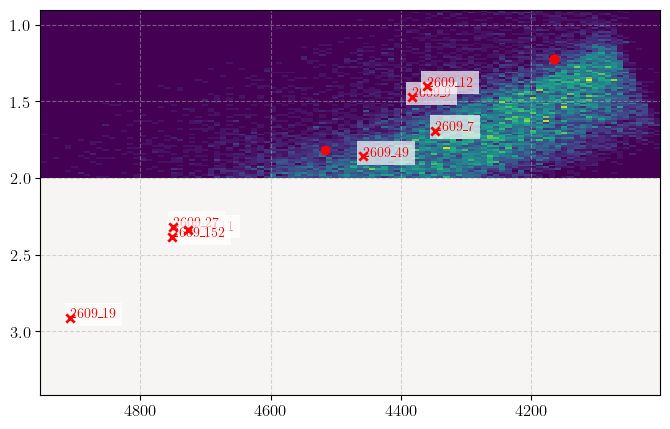

In [46]:
fig, ax = plt.subplots()
plt.hist2d(allstar['TEFF'], allstar['LOGG'], bins = 100)
[plt.text(m71_catalog.loc[i, 'teff'], m71_catalog.loc[i, 'logg'], m71_catalog.loc[i, 'source_name'], color = 'red', bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")) for i in range(len(m71_catalog))]
plt.scatter(m71_catalog['teff'], m71_catalog['logg'], c = 'red', marker = 'x', zorder = 11)
plt.scatter(usable['Teff_interp'], usable['logg_interp'], c = 'red', marker = 'o', zorder = 20)
ax.set_ylim(min(m71_catalog['logg']) - 0.5, max(m71_catalog['logg']) + 0.5)
# ax.set_xlim(min(m71_catalog['teff']) + 200, max(m71_catalog['teff']) - 200)
ax.invert_yaxis()
ax.invert_xaxis()
plt.show()

In [ ]:
#clip
max_teff = max(allstar['TEFF'])
min_teff = min(allstar['TEFF'])

max_logg = max(allstar['LOGG'])
min_logg = min(allstar['LOGG'])

sources_in_cut = source_df.loc[(source_df['teff'] < max_teff) & (source_df['teff'] > min_teff)]
sources_in_cut = sources_in_cut.loc[(sources_in_cut['logg'] < max_logg) & (sources_in_cut['logg'] > min_logg)]
sources_in_cut.reset_index(inplace = True)

In [ ]:
idxs = allstar.loc[allstar['APOGEE_ID'].isin(sources_in_cut['apogee_id'])].index

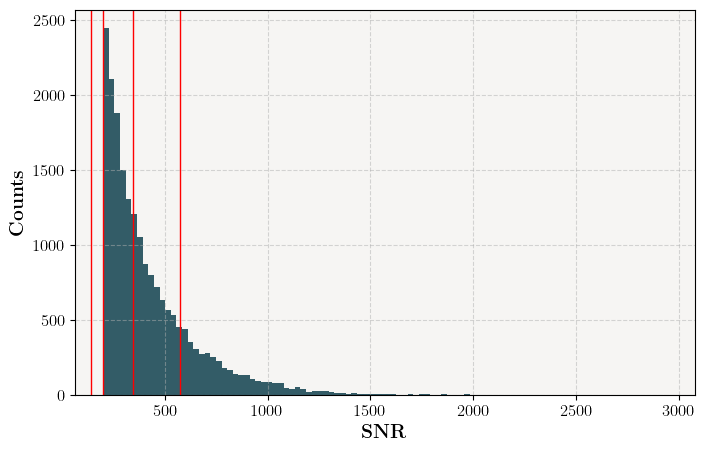

In [ ]:
#is snr my issue?

plt.hist(allstar['SNR'], bins = 100, color = cs[0])
[plt.axvline(snr, color = 'red', linewidth = 1) for snr in sources_in_cut['snr']]
plt.xlabel(r'\textbf{SNR}')
plt.ylabel(r'\textbf{Counts}')
plt.show()

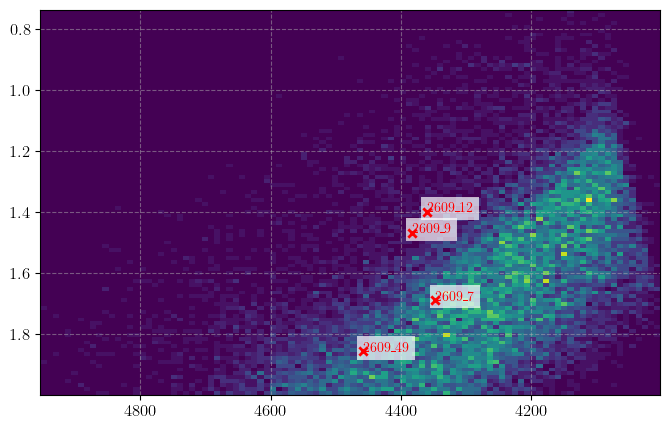

In [ ]:
# Replot
fig, ax = plt.subplots()
plt.hist2d(allstar['TEFF'], allstar['LOGG'], bins = 100)
[plt.text(sources_in_cut.loc[i, 'teff'], sources_in_cut.loc[i, 'logg'], sources_in_cut.loc[i, 'source_name'], color = 'red', bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")) for i in range(len(sources_in_cut))]
plt.scatter(source_df['teff'], source_df['logg'], c = 'red', marker = 'x', zorder = 11)

ax.invert_yaxis()
ax.invert_xaxis()
plt.show()

## **Find Closest Matches**

In [ ]:
#columns for euclid distance
dist_cols = ['teff', 'logg'] + [col for col in sources_in_cut.columns if '_fe' in col or '_h' in col]
dist_measure_jwst = sources_in_cut[dist_cols]
dist_measure_jwst.columns = [col.upper() for col in dist_cols]
dist_cols = [col.upper() for col in dist_cols]
dist_cols = ['TEFF', 'LOGG', 'C_FE', 'FE_H', 'MG_FE']

NameError: name 'sources_in_cut' is not defined

In [ ]:
distances = pd.DataFrame()
distances2 = pd.DataFrame()
for i, star in dist_measure_jwst.iterrows():
    distance =  ((star - allstar[dist_cols])**2).sum(axis=1)
    distances['{}'.format(sources_in_cut.loc[i, 'source_name'])] = distance


In [ ]:
#find closest match
closest_matches = [(src, distances.loc[(min(distances[src]) == distances[src])].index[0]) for src in sources_in_cut['source_name']]
match1 = closest_matches[3]

## **WL Grid**

In [ ]:
## Load in JWST files ## 
LOCAL_DATA_DIR = Path('/geir_data/scr/nwolfish/DATA')
jwst_spec_file = LOCAL_DATA_DIR / 'JWST_APOGEE.h5'
jwst_wave = pd.read_hdf(jwst_spec_file, 'wavelength').iloc[0].values
jwst_labels = pd.read_hdf(jwst_spec_file, 'labels')
jwst_spectra = pd.read_hdf(jwst_spec_file, 'spectra')
jwst_spectra.reset_index(drop=True, inplace=True)
jwst_labels.reset_index(drop=True, inplace=True) 

In [14]:
match1

('2609_49', np.int64(12616))

In [15]:
## real JWST Data
REAL_DATA_DIR = Path('DATA/exp_2')
exp_2_list = list(REAL_DATA_DIR.glob('*'))
match_f = [[fname for fname in exp_2_list if match[0] in fname.name] for match in closest_matches]

1


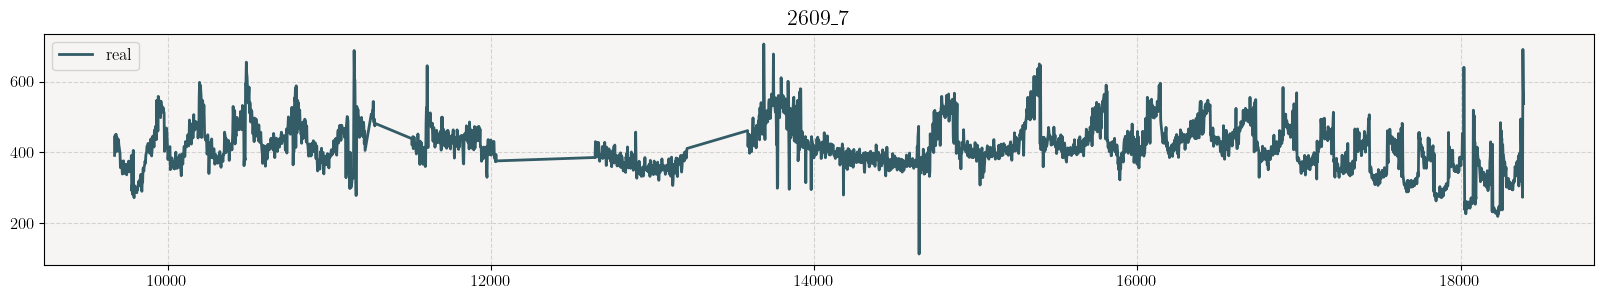

2


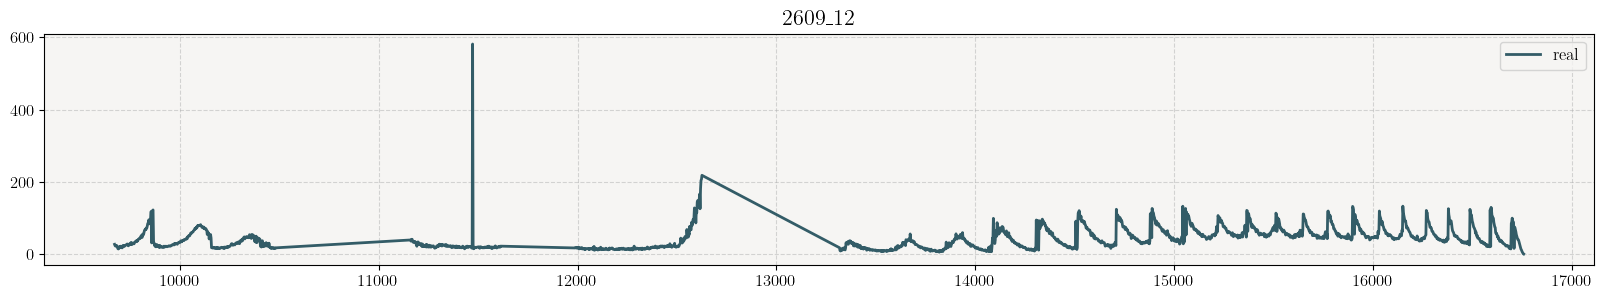

1


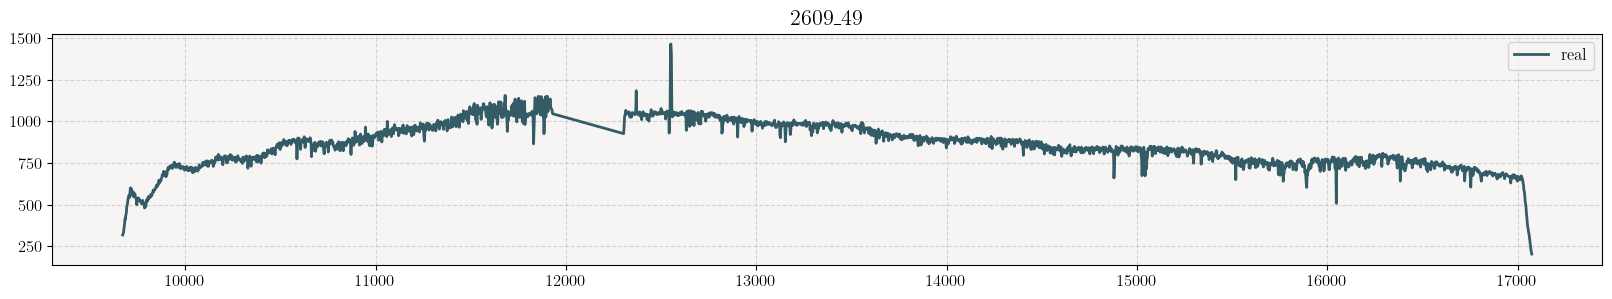

In [16]:
plot_path = Path('/geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/M71/plots')
plot_path.mkdir(exist_ok = True)

for i, match in enumerate(match_f):
    if len(match) > 0:
        sobjs = specobjs.SpecObjs.from_fitsfile(match[0])
        print(len(sobjs))
        very_small = (sobjs[0]['OPT_COUNTS'] < -100) | (sobjs[0]['OPT_COUNTS'] > 5000)
        new_mask = sobjs[0]['OPT_MASK'].copy()
        new_mask[very_small] = False

        plt.figure(figsize = (20, 3))
        plt.plot(sobjs[0]['OPT_WAVE'][new_mask], sobjs[0]['OPT_COUNTS'][new_mask], label = 'real', color = cs[0])
        plt.title(closest_matches[i][0])
        plt.savefig(plot_path / f'exp_2_{closest_matches[i][0]}.png')
        plt.legend()
        plt.show()

In [17]:
#LOAD REAL SPEC
spec_49 = match_f[-1][0]

sobjs = specobjs.SpecObjs.from_fitsfile(spec_49)
real_scaler = MinMaxScaler()
y_real_scaled = real_scaler.fit_transform(sobjs['OPT_COUNTS'][sobjs['OPT_MASK']].reshape(-1, 1))

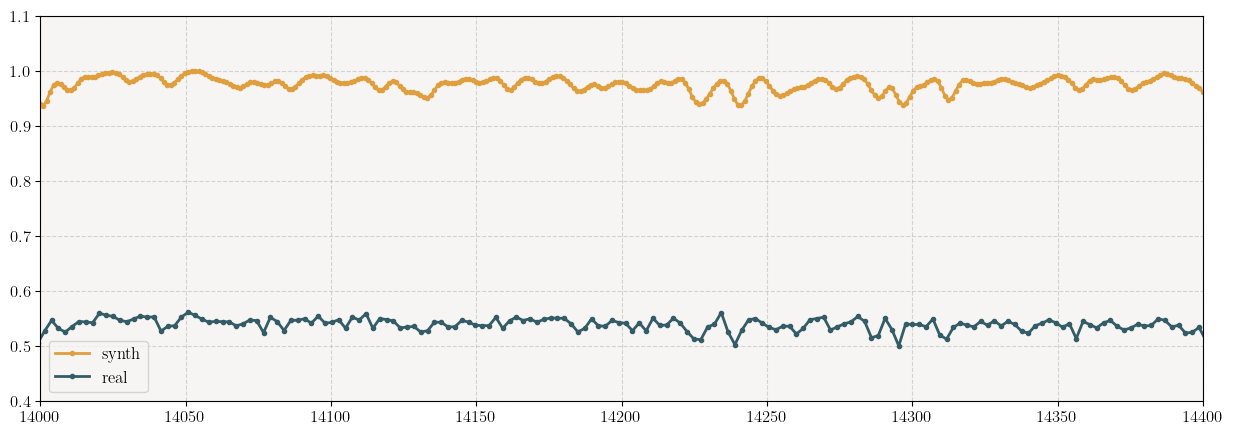

In [27]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlim(14000, 14400)
ax.set_ylim(0.4, 1.1)
ax.plot(jwst_spectra.columns, jwst_spectra.loc[match1[1]], label='synth', color=cs[2], marker = '.')
ax.plot(sobjs['OPT_WAVE'][sobjs['OPT_MASK']], y_real_scaled, label='real', color=cs[0], marker = '.')

ax.legend()
plt.show()

In [29]:
synth_grid = jwst_spectra.columns
real_grid = sobjs['OPT_WAVE'][sobjs['OPT_MASK']]

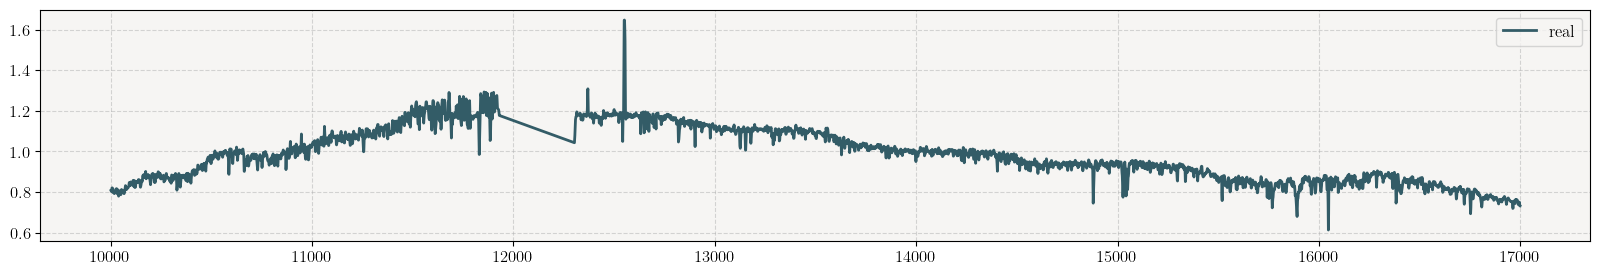

In [30]:
cuts = [10000, 17000]
# 1. Define a common grid
x_common = synth_grid[(synth_grid >= cuts[0]) & (synth_grid <= cuts[1])]

# 2. Interpolators
f_real  = interp1d(real_grid,  sobjs['OPT_COUNTS'][sobjs['OPT_MASK']],  kind='linear', bounds_error = False, fill_value=1)

# 3. Interpolated signals
y_real_interp  = f_real(x_common)
y_synth_interp = jwst_spectra.loc[match1[1], (jwst_spectra.columns >= cuts[0]) & (jwst_spectra.columns <= cuts[1])].values 
# 4. Plot
plt.figure(figsize=(20, 3))
# plt.plot(x_common, y_synth_interp, label="synth", color = cs[2])
plt.plot(x_common, y_real_interp / np.mean(y_real_interp), label="real", color = cs[0])
plt.legend()
plt.show()

## **Doppler Shift**

In [31]:
#reload spec 49
sobjs = specobjs.SpecObjs.from_fitsfile(spec_49)
#wavelength grid for correction 
wavelength_grid = sobjs['OPT_WAVE'][sobjs['OPT_MASK']]


In [32]:
def doppler_shift(wave, rv):
    """Applies a Doppler shift to the given wavelength array.

    Parameters:
    wave (np.ndarray): The original wavelength array.
    rv (float): The Doppler shift to apply.

    Returns:
    np.ndarray: The Doppler-shifted wavelength array.
    """
    return wave * (1 - rv / 3e5)  # Assuming v is in km/s

In [33]:
def chi_squared(synth, dop_shift, spec_unc):
    """Calculates the chi-squared statistic between synthetic and doppler shifted data.

    Parameters:
    synth (np.ndarray): The synthetic data.
    dop_shift (np.ndarray): The doppler shifted data.
    spec_unc (np.ndarray): The uncertainty in the spectrum.

    Returns:
    float: The chi-squared statistic.
    """
    return abs(np.sum((dop_shift - synth) ** 2 / spec_unc**2)) #divided by real uncertainty. try with and without

In [34]:
# arXiv:2004.07305v1 has rv = −22.9 ± 2.2 
centre_rv = -22.9
rvs = np.linspace(centre_rv - 20, centre_rv + 20, 10000)

In [35]:
sobjs = specobjs.SpecObjs.from_fitsfile(spec_49)
#wavelength grid for correction 
wl_grid = sobjs['OPT_WAVE'][sobjs['OPT_MASK']]
wl_lims = [13000, 13250]
wl_grid_cut = wl_grid[(wl_grid >= wl_lims[0]) & (wl_grid <= wl_lims[1])]

# cut real spec
real_spec = sobjs['OPT_COUNTS'][sobjs['OPT_MASK']]
real_spec_cut = real_spec[(wl_grid >= wl_lims[0]) & (wl_grid <= wl_lims[1])]

#spec unc
spec_unc = sobjs['OPT_COUNTS_SIG'][sobjs['OPT_MASK']] #IS THIS RIGHT??
spec_unc_cut = spec_unc[(wl_grid >= wl_lims[0]) & (wl_grid <= wl_lims[1])]

synth_spec = jwst_spectra.loc[match1[1]].values
synth_grid = jwst_spectra.columns.values

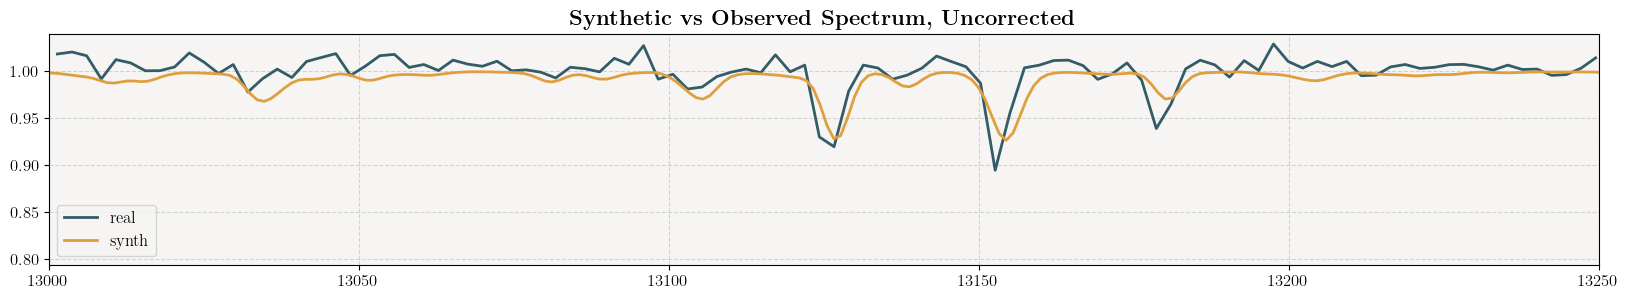

In [36]:
# plot both 
plt.figure(figsize = (20, 3))
plt.plot(wl_grid_cut, real_spec_cut / np.mean(real_spec_cut), label = 'real', color = cs[0])
plt.plot(synth_grid, synth_spec, label = 'synth', color = cs[2])
plt.xlim(wl_lims)
plt.legend()
plt.title(r'\textbf{Synthetic vs Observed Spectrum, Uncorrected}')
plt.show()

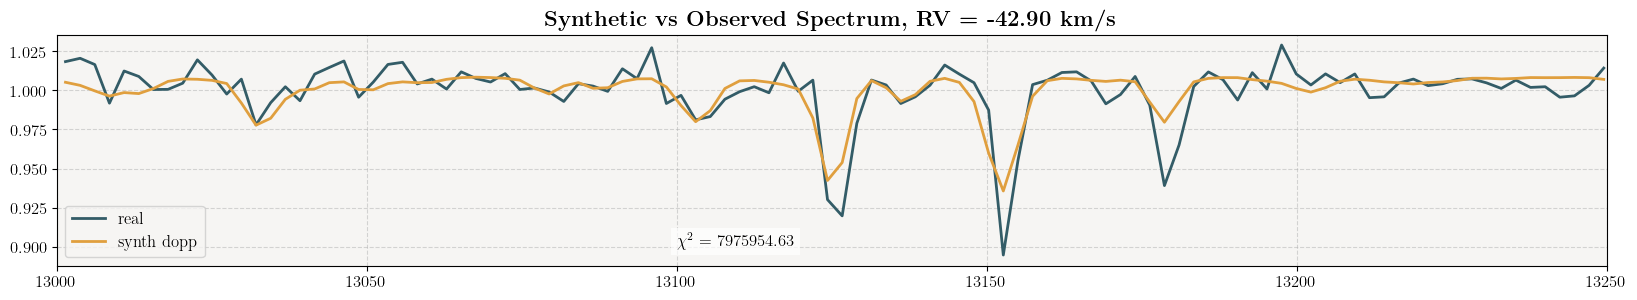

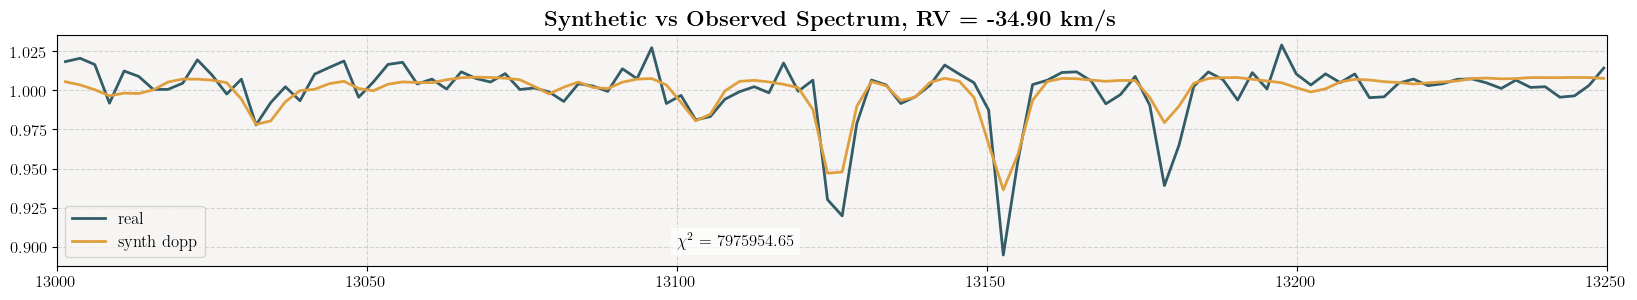

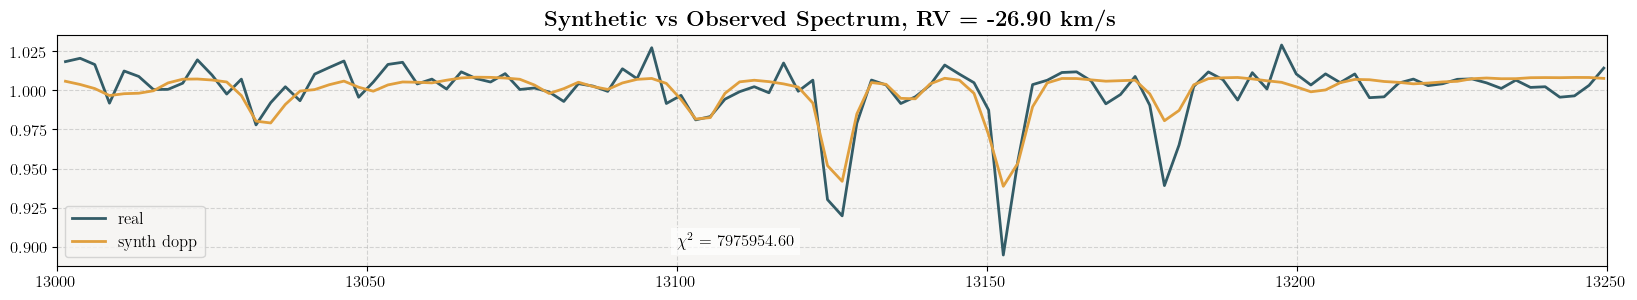

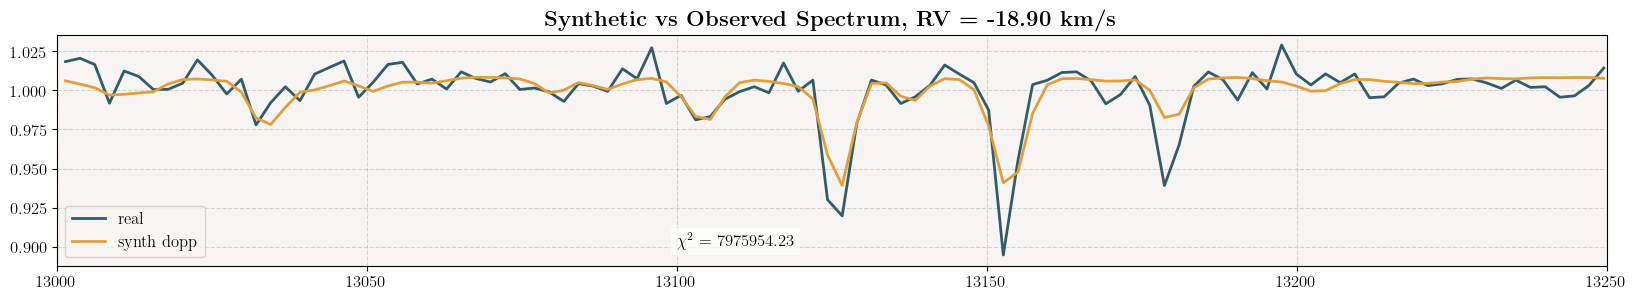

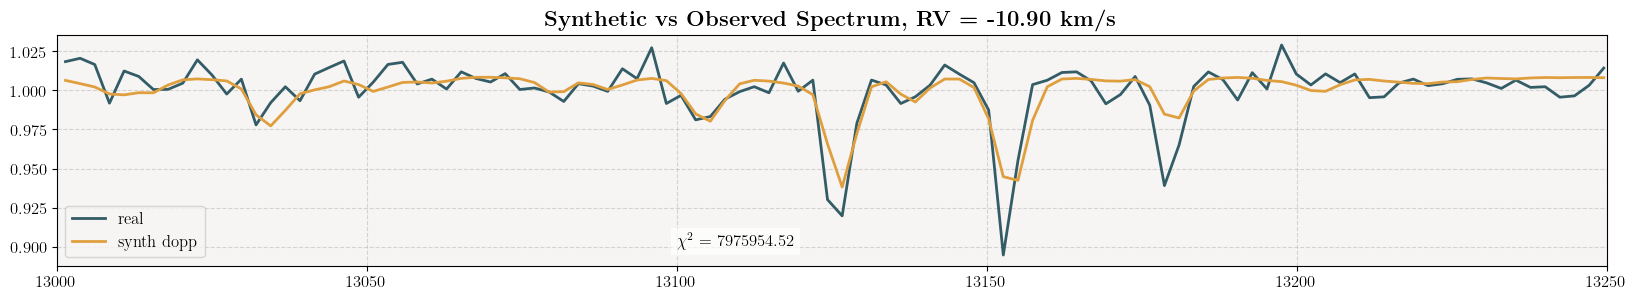

In [37]:
#step 1: doppler correct synth spectrum
chi2s = []
plot = False
for i, rv in enumerate(rvs):
    #step 1: doppler correct synth spectrum
    synth_grid_dopp = doppler_shift(synth_grid, -rv)

    # step 2: select grid points and spectral points within limits
    within_lims = (synth_grid_dopp > wl_lims[0]) & (synth_grid_dopp < wl_lims[1])
    synth_grid_dopp_cut = synth_grid_dopp[within_lims]
    synth_spec_cut = synth_spec[within_lims]

    # step 2: interpolate to real wavelength grid
    wl_grid_clipped = np.clip(wl_grid_cut, synth_grid_dopp_cut.min(), synth_grid_dopp_cut.max()) #so no errors
    interpolator = interp1d(synth_grid_dopp_cut, synth_spec_cut, kind='linear', fill_value=0)
    synth_spec_real_grid = interpolator(wl_grid_clipped)

    # determine chi squared
    chi_sq = chi_squared(synth_spec_real_grid, real_spec_cut, spec_unc_cut)
    chi2s.append(chi_sq)

    if i % 2000 == 0:
        plt.figure(figsize = (20, 3))
        plt.plot(wl_grid_cut, real_spec_cut / np.mean(real_spec_cut), label = 'real', color = cs[0])
        plt.plot(wl_grid_cut, synth_spec_real_grid / np.mean(synth_spec_real_grid), label = 'synth dopp', color = cs[2])
        plt.xlim(wl_lims)
        plt.text(13100, 0.9, r'$\chi^2$ = %.2f' % chi_sq, fontsize=12, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
        plt.title(r'\textbf{Synthetic vs Observed Spectrum, RV = %.2f km/s}' % rv)
        plt.legend()
        plt.show()


chi2s = np.array(chi2s)

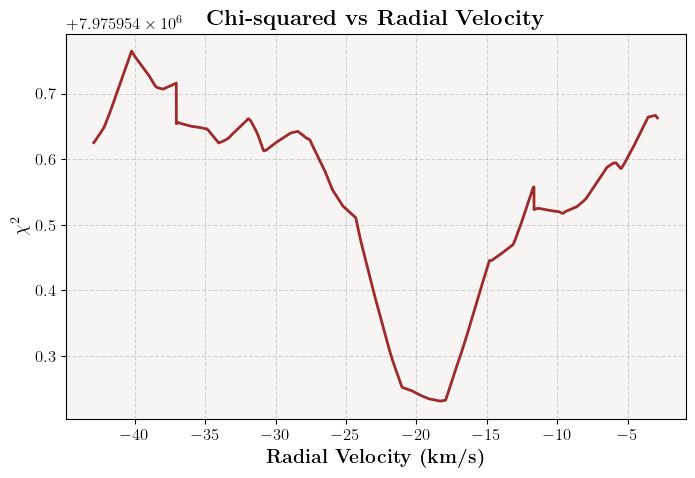

In [38]:
plt.plot(rvs, chi2s, color = cs[3])
plt.xlabel(r'\textbf{Radial Velocity (km/s)}')
plt.ylabel(r'\textbf{$\chi^2$}')
plt.title(r'\textbf{Chi-squared vs Radial Velocity}')
plt.show()

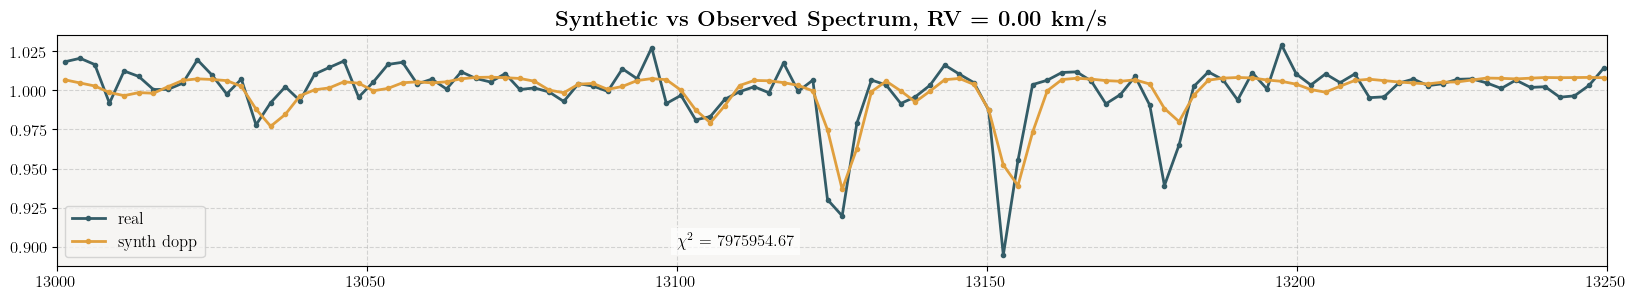

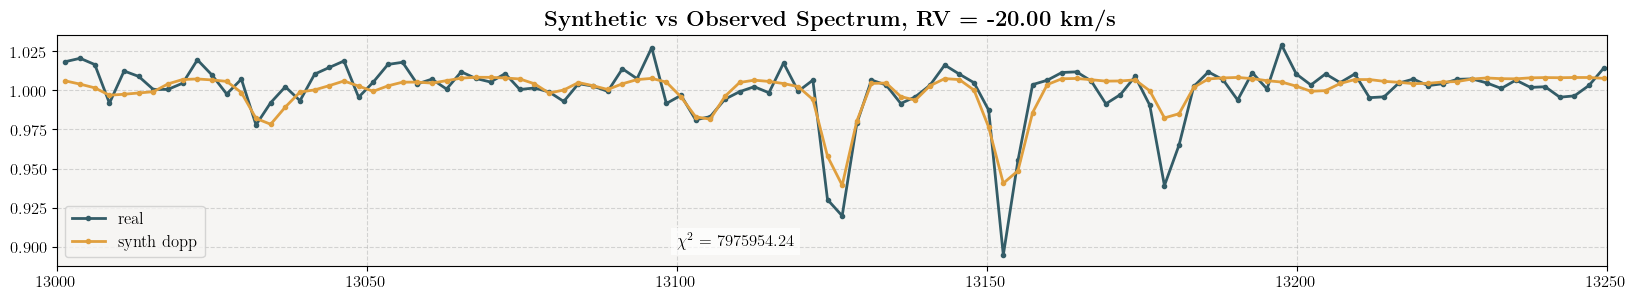

In [39]:
two_rvs = [0, -20.00]

#best rv
for rv in two_rvs:

    #final correction plot
    #step 1: doppler correct synth spectrum
    synth_grid_dopp = doppler_shift(synth_grid, -rv)

    # step 2: select grid points and spectral points within limits
    within_lims = (synth_grid_dopp > wl_lims[0]) & (synth_grid_dopp < wl_lims[1])
    synth_grid_dopp_cut = synth_grid_dopp[within_lims]
    synth_spec_cut = synth_spec[within_lims]

    # step 2: interpolate to real wavelength grid
    wl_grid_clipped = np.clip(wl_grid_cut, synth_grid_dopp_cut.min(), synth_grid_dopp_cut.max()) #so no errors
    interpolator = interp1d(synth_grid_dopp_cut, synth_spec_cut, kind='linear', fill_value=0)
    synth_spec_real_grid = interpolator(wl_grid_clipped)

    # determine chi squared
    chi_sq = chi_squared(synth_spec_real_grid, real_spec_cut, spec_unc_cut)

    plt.figure(figsize = (20, 3))
    plt.plot(wl_grid_cut, real_spec_cut / np.mean(real_spec_cut), label = 'real', color = cs[0], 
            marker = '.')
    plt.plot(wl_grid_cut, synth_spec_real_grid / np.mean(synth_spec_real_grid), label = 'synth dopp', color = cs[2], marker = '.')
    plt.xlim(wl_lims)
    plt.text(13100, 0.9, r'$\chi^2$ = %.2f' % chi_sq, fontsize=12, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    plt.title(r'\textbf{Synthetic vs Observed Spectrum, RV = %.2f km/s}' % rv)
    plt.legend()
    plt.show()

In [40]:
best_rv = rvs[np.argmin(chi2s)]
print('Best RV: ', best_rv)

Best RV:  -18.289538953895388


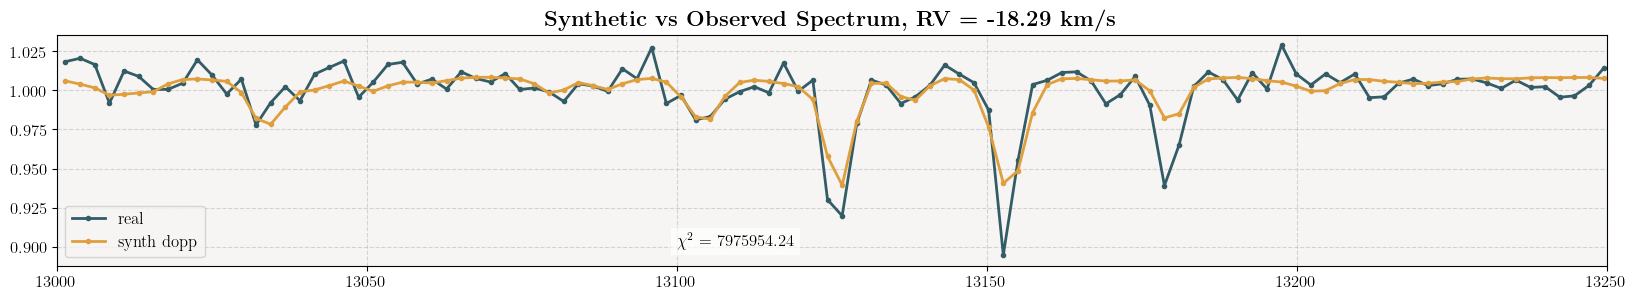

In [41]:
plt.figure(figsize = (20, 3))
plt.plot(wl_grid_cut, real_spec_cut / np.mean(real_spec_cut), label = 'real', color = cs[0], 
         marker = '.')
plt.plot(wl_grid_cut, synth_spec_real_grid / np.mean(synth_spec_real_grid), label = 'synth dopp', color = cs[2], marker = '.')
plt.xlim(wl_lims)
plt.text(13100, 0.9, r'$\chi^2$ = %.2f' % chi_sq, fontsize=12, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
plt.title(r'\textbf{Synthetic vs Observed Spectrum, RV = %.2f km/s}' % best_rv)
plt.legend()
plt.show()

In [42]:
xmatch = pd.read_csv('M71_xmatch_sources.csv')

## **Gaussian Fit**

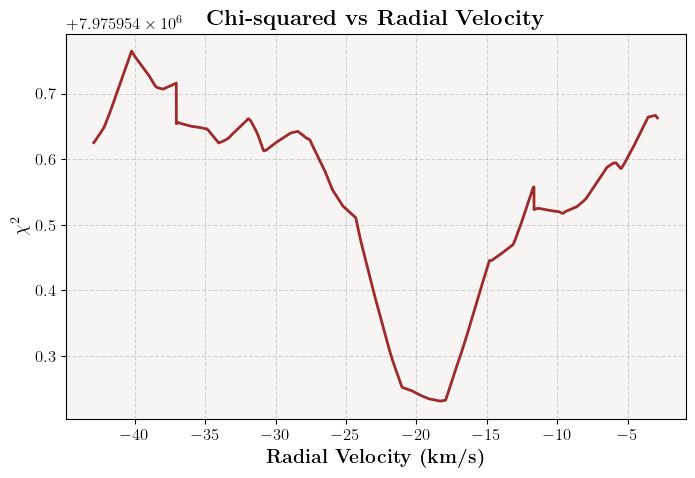

In [43]:
plt.plot(rvs, chi2s, color = cs[3])
plt.xlabel(r'\textbf{Radial Velocity (km/s)}')
plt.ylabel(r'\textbf{$\chi^2$}')
plt.title(r'\textbf{Chi-squared vs Radial Velocity}')
plt.show()

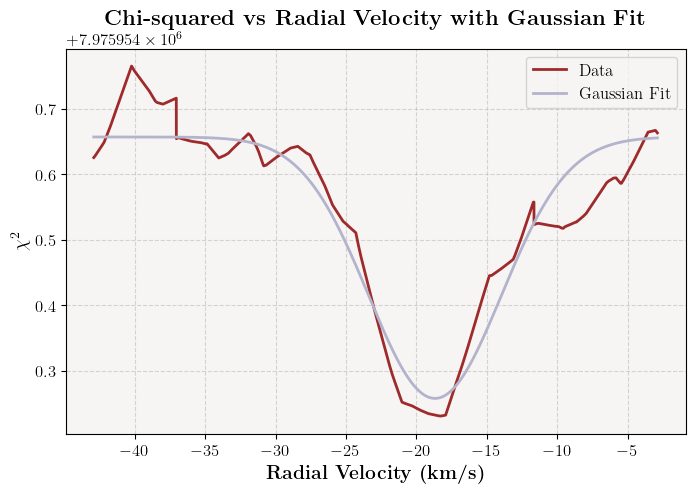

In [44]:
# fit gaussian to chi2s
from scipy.optimize import curve_fit
def gaussian(x, amp, mean, stddev, offset):
    """Gaussian function.
    Parameters:
    x (np.ndarray): The input array.
    amp (float): Amplitude of the Gaussian.
    mean (float): Mean of the Gaussian.
    stddev (float): Standard deviation of the Gaussian.
    offset (float): Vertical offset.
    Returns:
    np.ndarray: The Gaussian evaluated at x.
    """
    return amp * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2)) + offset
popt, pcov = curve_fit(gaussian, rvs, chi2s, p0=[max(chi2s), best_rv, 5, min(chi2s)])
plt.plot(rvs, chi2s, color = cs[3], label = 'Data')
plt.plot(rvs, gaussian(rvs, *popt), color = cs[5], label = 'Gaussian Fit')
plt.xlabel(r'\textbf{Radial Velocity (km/s)}')
plt.ylabel(r'\textbf{$\chi^2$}')
plt.title(r'\textbf{Chi-squared vs Radial Velocity with Gaussian Fit}')
plt.legend()
plt.show()


## **try with my script** 

In [45]:
# grab real spec
real_spec = sobjs['OPT_COUNTS'][sobjs['OPT_MASK']]
real_grid = sobjs['OPT_WAVE'][sobjs['OPT_MASK']]
spec_unc = sobjs['OPT_COUNTS_SIG'][sobjs['OPT_MASK']] 

# grab synth spec
synth_spec = jwst_spectra.loc[match1[1]].values
synth_grid = jwst_spectra.columns.values

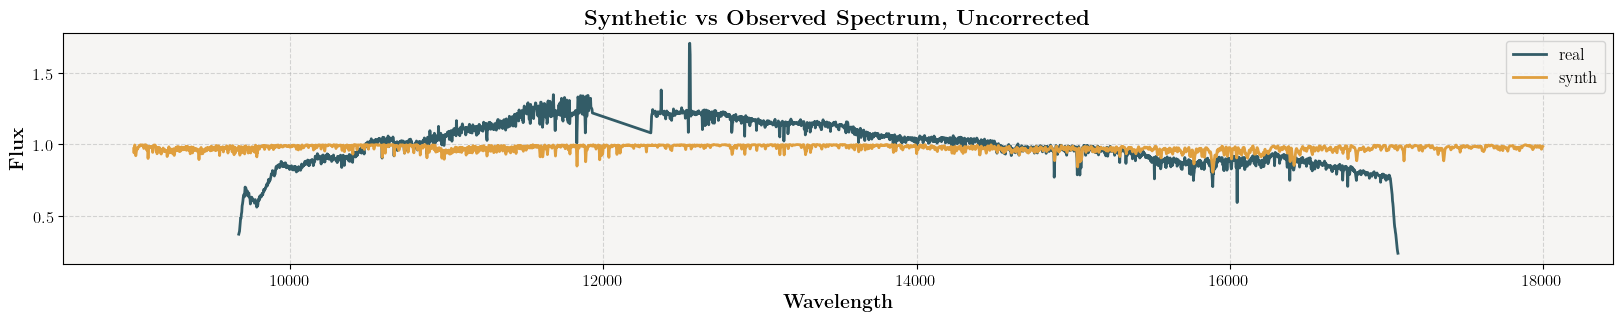

In [46]:
plt.figure(figsize = (20, 3))
plt.plot(real_grid, real_spec / np.mean(real_spec), label = 'real', color = cs[0])
plt.plot(synth_grid, synth_spec, label = 'synth', color = cs[2])
plt.xlabel(r'\textbf{Wavelength}')
plt.ylabel(r'\textbf{Flux}')
plt.title(r'\textbf{Synthetic vs Observed Spectrum, Uncorrected}')
plt.legend()
plt.show()

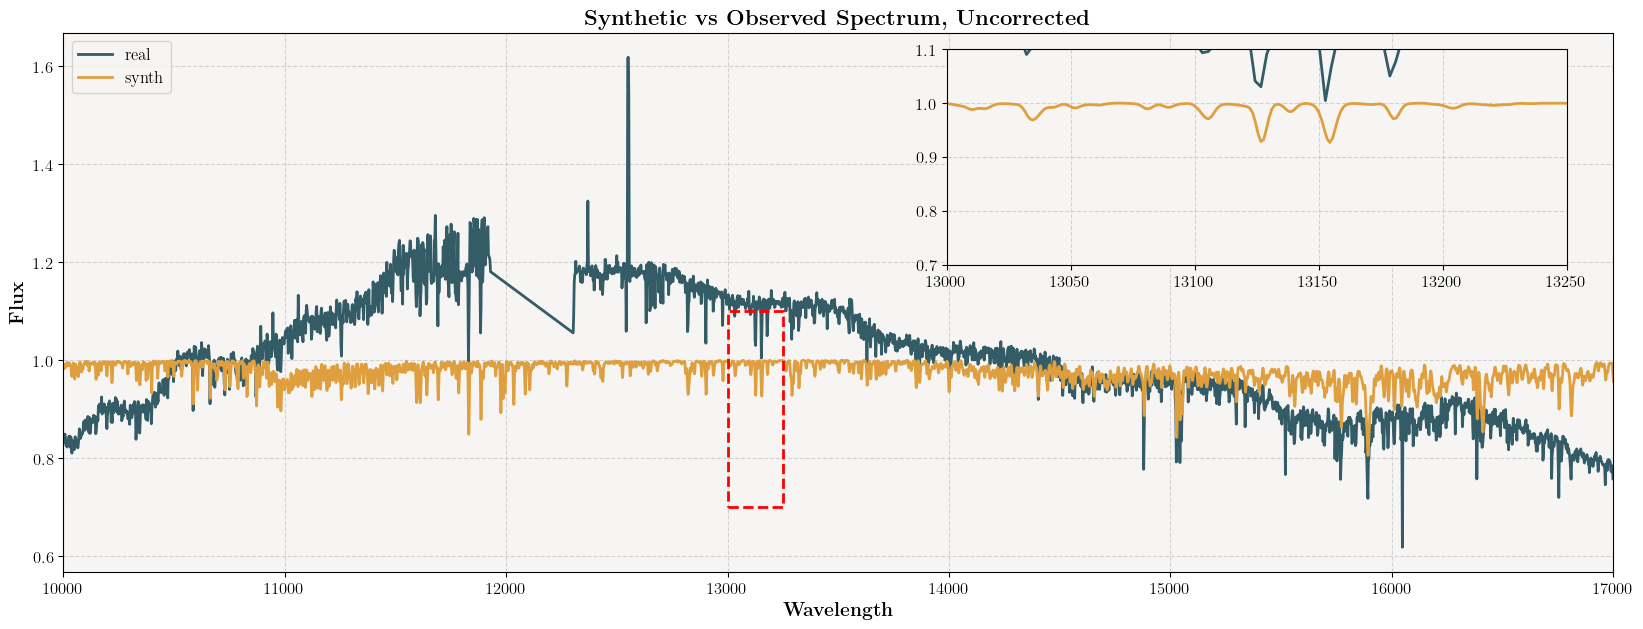

In [47]:
# crop
crop_edges = [10000, 17000]
real_mask = (real_grid >= crop_edges[0]) & (real_grid <= crop_edges[1])
real_grid = real_grid[real_mask]
real_spec = real_spec[real_mask]
spec_unc = spec_unc[real_mask]

# normalize
real_spec_scaler = MinMaxScaler()
real_spec = real_spec_scaler.fit_transform(real_spec.reshape(-1, 1)).flatten()
real_spec = real_spec - np.mean(real_spec) + 1 #center around 1

wl_lims = [13000, 13250] # select spectral features to fit to

# plot both
fig, ax = plt.subplots(figsize = (20, 7))
ax.plot(real_grid, real_spec, label = 'real', color = cs[0])
ax.plot(synth_grid, synth_spec, label = 'synth', color = cs[2])
rect = patches.Rectangle((wl_lims[0], 0.7), wl_lims[1]-wl_lims[0], 0.4, linewidth=2, edgecolor='r', facecolor='none', linestyle='--', zorder=10)
ax.add_patch(rect)

ax_in = ax.inset_axes([0.57, 0.57, 0.4, 0.4])
ax_in.plot(real_grid, real_spec, label = 'real', color = cs[0])
ax_in.plot(synth_grid, synth_spec, label = 'synth', color = cs[2])
ax_in.set_xlim(wl_lims)
ax_in.set_ylim(0.7, 1.1)

ax.set_xlabel(r'\textbf{Wavelength}')
ax.set_ylabel(r'\textbf{Flux}')
ax.set_title(r'\textbf{Synthetic vs Observed Spectrum, Uncorrected}')
ax.set_xlim(crop_edges)
# ax.set_ylim(0.6, 1)
ax.legend(loc ='upper left')
plt.show()

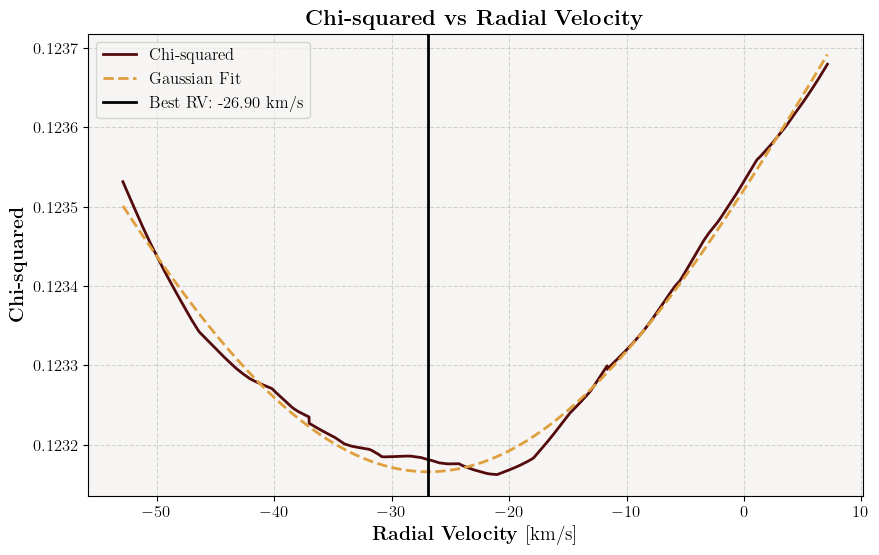

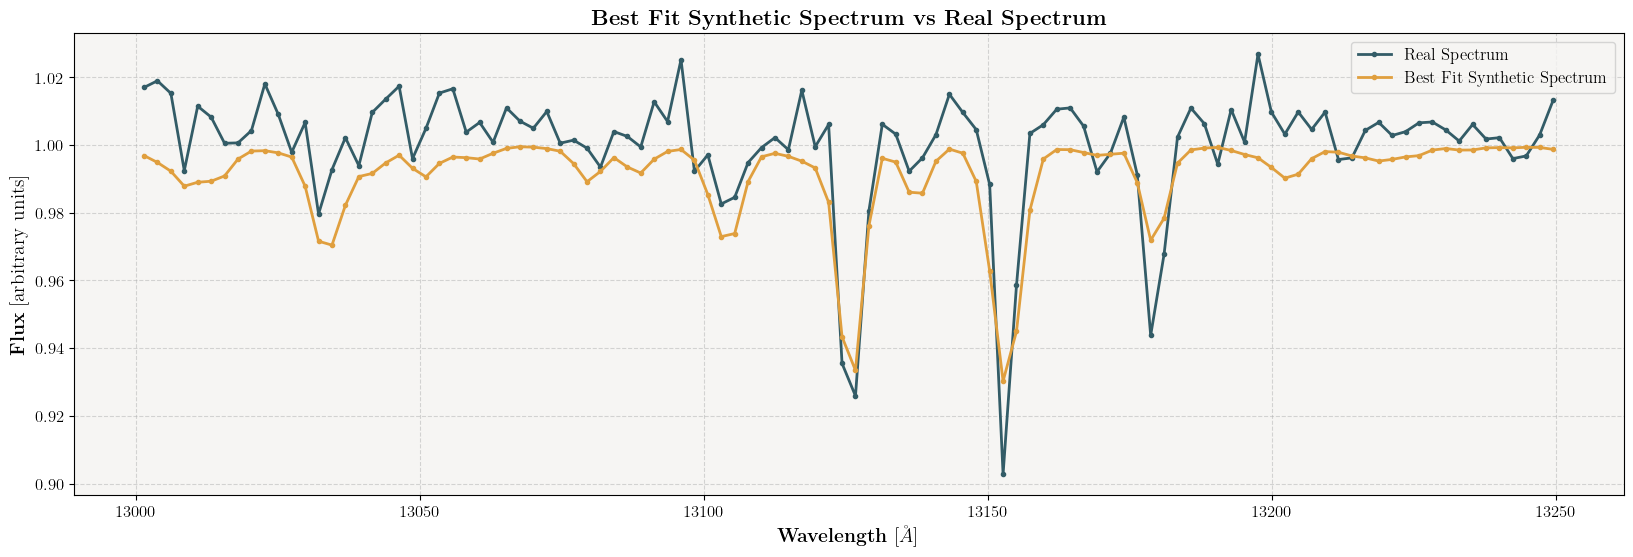

Best RV from function:  -26.89933900788716


In [48]:
best_rv = rfc.rest_frame_correction(real_grid, synth_grid, real_spec, synth_spec, spec_unc, central_rv = -22.9, wl_lims = wl_lims, plot=True)
print('Best RV from function: ', best_rv)


In [49]:
real_grid_dopp = rfc.doppler_shift(real_grid, best_rv)

## **Quadratic Ctm Fit**

In [50]:
def quadratic(x, a, b, c):
    """ Quadratic function.
    Parameters:
    x (np.ndarray): The input array.
    a (float): Quadratic coefficient.
    b (float): Linear coefficient.
    c (float): Constant term.
    Returns:
    np.ndarray: The quadratic evaluated at x.
    """
    return a * x**2 + b * x + c

def quartic(x, a, b, c, d, e):
    """ Quartic function.
    Parameters:
    x (np.ndarray): The input array.
    a (float): Quartic coefficient.
    b (float): Cubic coefficient.
    c (float): Quadratic coefficient.
    d (float): Linear coefficient.
    e (float): Constant term.
    Returns:
    np.ndarray: The quartic evaluated at x.
    """
    return a * x**4 + b * x**3 + c * x**2 + d * x + e

In [51]:
detector_gap_idx = np.argmax(np.diff(real_grid)) + 1 #+1 to get start of right side
print('Detector gap index: ', detector_gap_idx)
#split into two regions
real_grid_left = real_grid[:detector_gap_idx] # Left side wavelengths
real_spec_left = real_spec[:detector_gap_idx] # Left side spectra
spec_unc_left = spec_unc[:detector_gap_idx] # Left side uncertainties
real_grid_right = real_grid[detector_gap_idx:] # Right side wavelengths
real_spec_right = real_spec[detector_gap_idx:] # Right side spectra
spec_unc_right = spec_unc[detector_gap_idx:] # Right side uncertainties

Detector gap index:  807


In [52]:
#fit to left side
popt_left, pcov_left = curve_fit(quadratic, real_grid_left, real_spec_left, sigma=spec_unc_left, absolute_sigma=True)
fitted_left = quadratic(real_grid_left, *popt_left) 
#fit to right side
popt_right, pcov_right = curve_fit(quadratic, real_grid_right, real_spec_right, sigma=spec_unc_right, absolute_sigma=True)
fitted_right = quadratic(real_grid_right, *popt_right) 

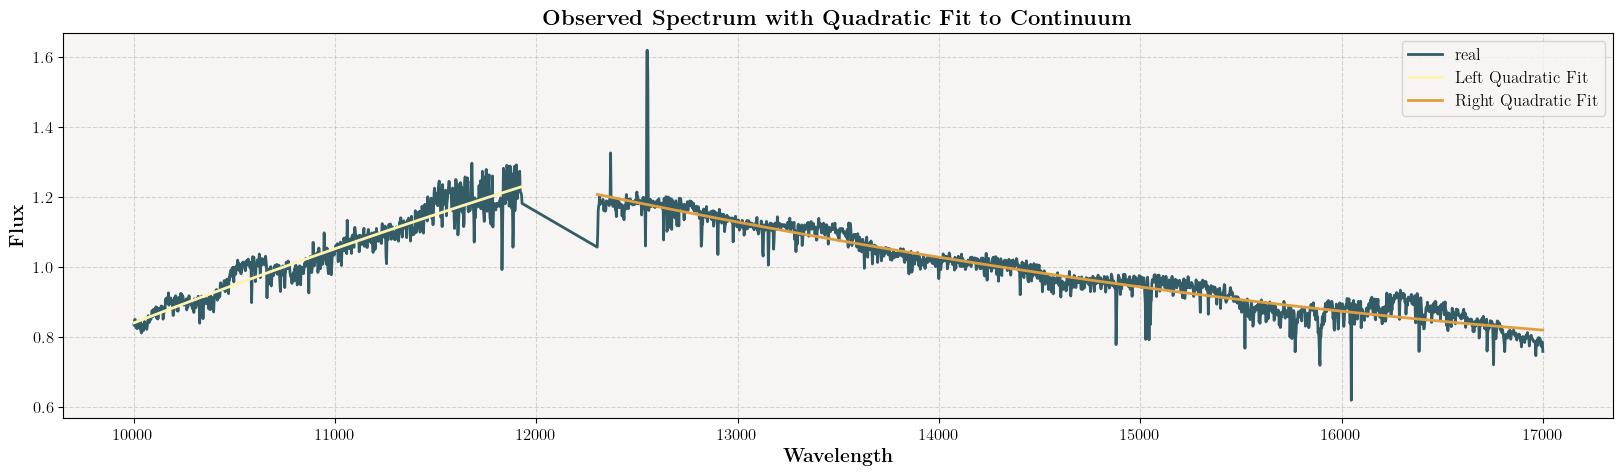

In [53]:
plt.subplots(figsize = (20, 5))
plt.plot(real_grid, real_spec, label = 'real', color = cs[0])
plt.xlabel(r'\textbf{Wavelength}')
plt.ylabel(r'\textbf{Flux}')
plt.title(r'\textbf{Observed Spectrum with Quadratic Fit to Continuum}')
plt.plot(real_grid_left, fitted_left, label = 'Left Quadratic Fit', color = cs[1], linewidth=2)
plt.plot(real_grid_right, fitted_right, label = 'Right Quadratic Fit', color = cs[2], linewidth=2)
plt.legend()
plt.show()

In [54]:
ctm_corrected_real_spec = real_spec.copy() / np.concatenate((fitted_left, fitted_right))

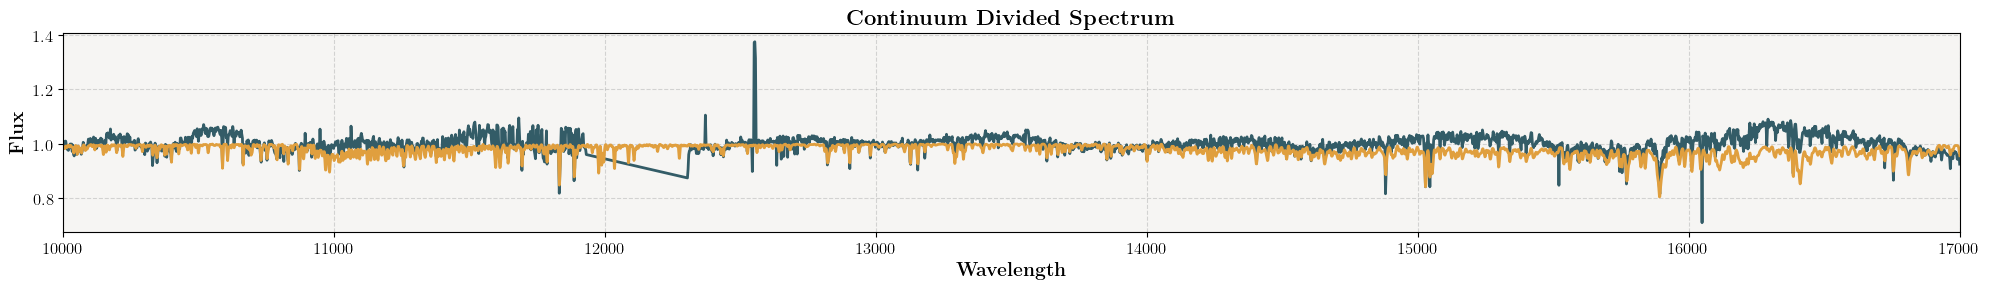

In [55]:
#try both subtracting and dividing
fig, ax = plt.subplots( figsize = (20, 3), sharex=True)

ax.plot(real_grid_dopp, real_spec / np.concatenate((fitted_left, fitted_right)), color = cs[0])
ax.plot(synth_grid, synth_spec, color = cs[2])

ax.set_title(r'\textbf{Continuum Divided Spectrum}')
ax.set_xlabel(r'\textbf{Wavelength}')
ax.set_ylabel(r'\textbf{Flux}')
ax.set_xlim(crop_edges)
plt.tight_layout()
plt.show()

## **Try modelling using a rolling mean**

In [56]:
def rolling_mean(data, window_size):
    """Calculates the rolling mean of the given data.

    Parameters:
    data (np.ndarray): The input data array.
    window_size (int): The size of the rolling window.

    Returns:
    np.ndarray: The rolling mean of the data.
    """
    rm = np.convolve(data, np.ones(window_size)/window_size, mode='same') #CHANGE TO MEDIAN
    # fix first window_size//2 and last window_size//2 points
    half_window = window_size // 2
    rm[:half_window] = np.median(data[:window_size])
    rm[-half_window:] = np.median(data[-window_size:])
    return rm

In [57]:
def rolling_median(data, window_size=50):
    """Calculates the rolling median of the given data.

    Parameters:
    data (np.ndarray): The input data array.
    window_size (int): The size of the rolling window.

    Returns:
    np.ndarray: The rolling median of the data.
    """
    rm = median_filter(data, size=window_size, mode='nearest')
    return rm

In [58]:
def identify_anomalies(data, continuum, sigma_threshold):
    """Identifies anomalies in the data that deviate from the continuum by a specified sigma threshold.

    Parameters:
    data (np.ndarray): The input data array.
    continuum (np.ndarray): The continuum array.
    sigma_threshold (float): The sigma threshold for identifying anomalies.

    Returns:
    tuple: A tuple containing the indices of anomalies and their corresponding values.
    """
    residuals = data - continuum
    std_dev = np.std(residuals)
    anomaly_mask = np.abs(residuals) > (sigma_threshold * std_dev)
    return anomaly_mask

In [59]:
real_rm_left = rolling_median(real_spec_left, window_size=50) #calculate rolling median for left side

#identify anomalies wihth 5 sigma and 3 sigma thresholds
mask5_left = identify_anomalies(real_spec_left, real_rm_left, sigma_threshold=5)
spec_anoms5_left = real_spec_left[mask5_left]
real_grid_anoms5_left = real_grid_left[mask5_left]

mask3_left = identify_anomalies(real_spec_left, real_rm_left, sigma_threshold=3)
spec_anoms3_left = real_spec_left[mask3_left]
real_grid_anoms3_left = real_grid_left[mask3_left]

real_rm_right = rolling_median(real_spec_right, window_size=50) #calculate rolling median for right side

#identify anomalies wihth 5 sigma and 3 sigma thresholds
mask5_right = identify_anomalies(real_spec_right, real_rm_right, sigma_threshold=5)
spec_anoms5_right = real_spec_right[mask5_right]
real_grid_anoms5_right = real_grid_right[mask5_right]
mask3_right = identify_anomalies(real_spec_right, real_rm_right, sigma_threshold=3)
spec_anoms3_right = real_spec_right[mask3_right]
real_grid_anoms3_right = real_grid_right[mask3_right]

#1 sigma
mask1_left = identify_anomalies(real_spec_left, real_rm_left, sigma_threshold=1)
spec_anoms1_left = real_spec_left[mask1_left]
real_grid_anoms1_left = real_grid_left[mask1_left]
mask1_right = identify_anomalies(real_spec_right, real_rm_right, sigma_threshold=1)
spec_anoms1_right = real_spec_right[mask1_right]
real_grid_anoms1_right = real_grid_right[mask1_right]

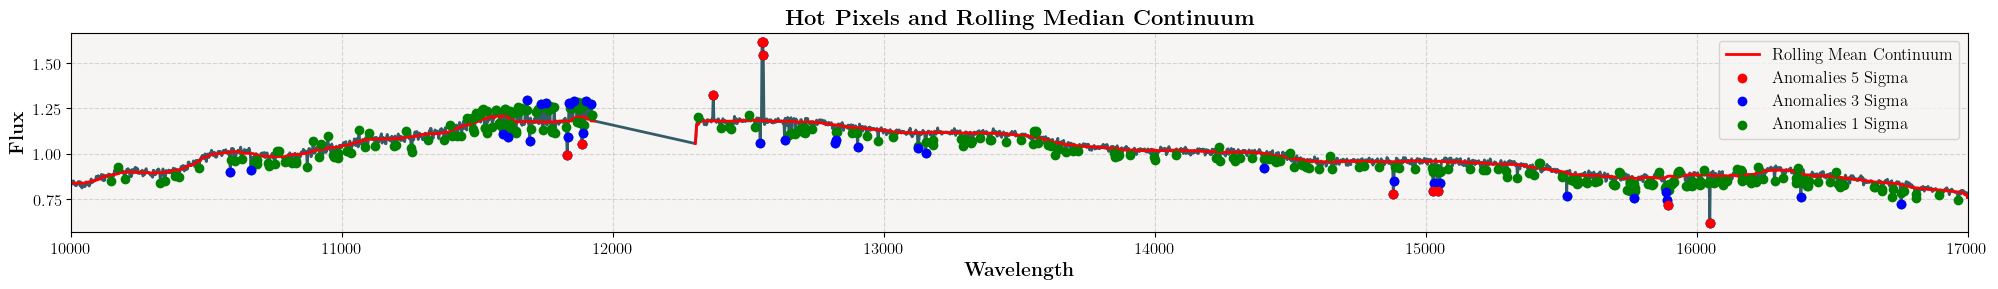

In [60]:
#plot
fig, ax = plt.subplots( figsize = (20, 3), sharex=True)

ax.plot(real_grid, real_spec, color = cs[0])
ax.plot(real_grid_left, real_rm_left, color = 'red', label = 'Rolling Mean Continuum', linewidth=2)
plt.scatter(real_grid_anoms5_left, spec_anoms5_left, color = 'red', label = 'Anomalies 5 Sigma', zorder=11)
plt.scatter(real_grid_anoms3_left, spec_anoms3_left, color = 'blue', label = 'Anomalies 3 Sigma', zorder=10)

ax.plot(real_grid_right, real_rm_right, color = 'red', linewidth=2)
plt.scatter(real_grid_anoms5_right, spec_anoms5_right, color = 'red', zorder=11)
plt.scatter(real_grid_anoms3_right, spec_anoms3_right, color = 'blue', zorder=10)
plt.scatter(real_grid_anoms1_left, spec_anoms1_left, color = 'green', label = 'Anomalies 1 Sigma', zorder=9)
plt.scatter(real_grid_anoms1_right, spec_anoms1_right, color = 'green', zorder=9)

ax.set_title(r'\textbf{Hot Pixels and Rolling Median Continuum}')
ax.set_xlabel(r'\textbf{Wavelength}')
ax.set_ylabel(r'\textbf{Flux}')
ax.set_xlim(crop_edges)
ax.legend()
plt.tight_layout()
plt.savefig('rm_ctm.png')
plt.show()

In [61]:
# select 1 sigma mask, combine left and right
mask1 = np.concatenate((mask1_left, mask1_right))
rm = np.concatenate((real_rm_left, real_rm_right))

In [62]:
# remove anomalies
real_grid_cleaned = real_grid_dopp[~mask1]
real_spec_ctm_pix = real_spec[~mask1]
spec_unc_cleaned = spec_unc[~mask1]

# recalculate rolling median on cleaned spectrum
real_rm_ctm = rolling_median(real_spec_ctm_pix, window_size=50)
# divide out rolling median
real_spec_cleaned = real_spec_ctm_pix / real_rm_ctm

In [66]:
#fit to left side
real_grid_left_masked = real_grid_left[~mask1_left]
real_spec_left_masked = real_spec_left[~mask1_left]
spec_unc_left_masked = spec_unc_left[~mask1_left]

popt_left, pcov_left = curve_fit(quadratic, real_grid_left_masked, real_spec_left_masked, sigma=spec_unc_left_masked, absolute_sigma=True)
fitted_left = quadratic(real_grid_left_masked, *popt_left) 

#fit to right side
real_grid_right_masked = real_grid_right[~mask1_right]
real_spec_right_masked = real_spec_right[~mask1_right]
spec_unc_right_masked = spec_unc_right[~mask1_right]

popt_right, pcov_right = curve_fit(quadratic, real_grid_right_masked, real_spec_right_masked, sigma=spec_unc_right_masked, absolute_sigma=True)
fitted_right = quadratic(real_grid_right_masked, *popt_right) 

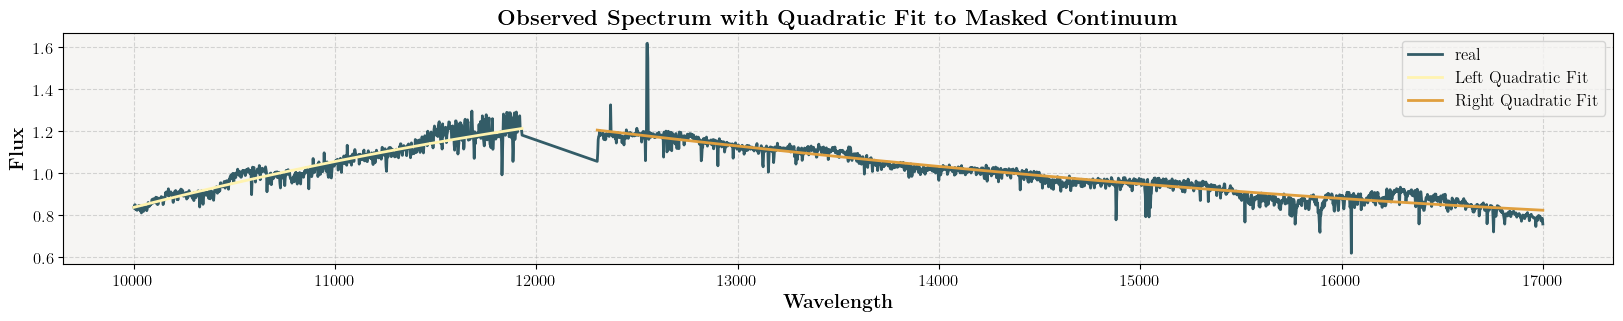

In [67]:
plt.subplots(figsize = (20, 3))
plt.plot(real_grid, real_spec, label = 'real', color = cs[0])
plt.xlabel(r'\textbf{Wavelength}')
plt.ylabel(r'\textbf{Flux}')
plt.title(r'\textbf{Observed Spectrum with Quadratic Fit to Masked Continuum}')
plt.plot(real_grid_left_masked, fitted_left, label = 'Left Quadratic Fit', color = cs[1], linewidth=2)
plt.plot(real_grid_right_masked, fitted_right, label = 'Right Quadratic Fit', color = cs[2], linewidth=2)
plt.legend()
plt.show()

In [ ]:
# divide out quadratic


In [69]:
fitted_quad

array([0.83653113, 0.83711474, 0.83769782, ..., 0.82318445, 0.82307164,
       0.82295914], shape=(2439,))

In [70]:
real_spec

array([0.83689818, 0.83182155, 0.84847103, ..., 0.78363154, 0.78432431,
       0.75771001], shape=(2813,))

## **Creating class**

In [111]:
import spectra as sp

In [112]:
spec49 = sp.Spectra(real_grid_cleaned, real_spec_cleaned, spec_unc_cleaned, synth_grid, synth_spec)

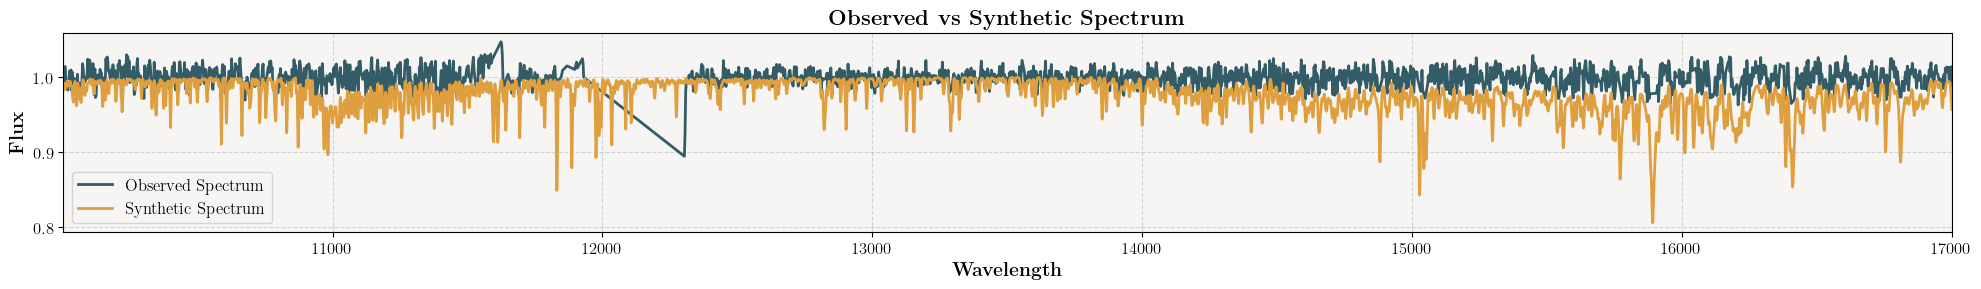

In [113]:
spec49.plot()

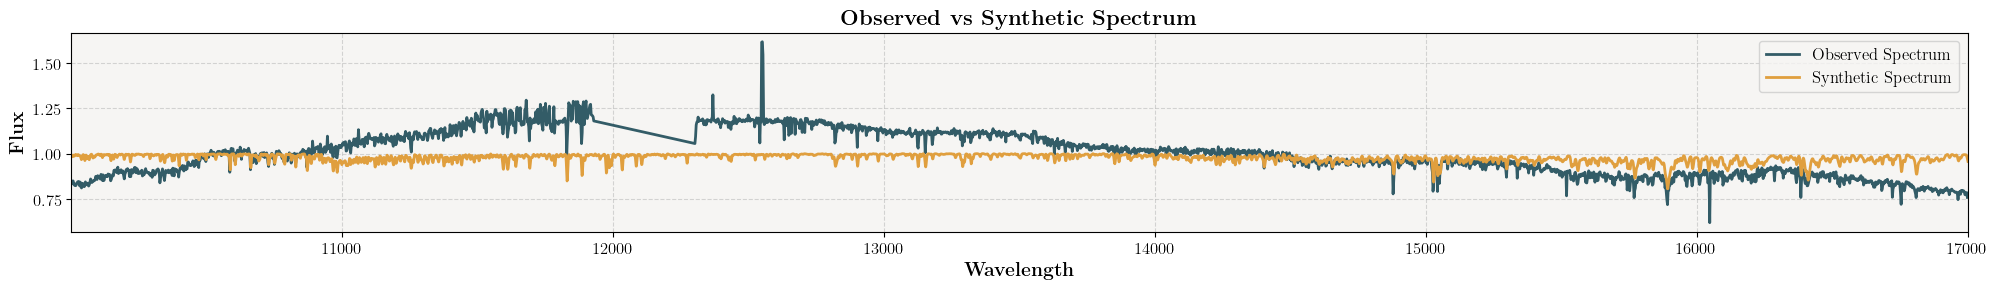

In [114]:
fig, ax = plt.subplots( figsize = (20, 3), sharex=True)

ax.plot(real_grid, real_spec, color = cs[0], label='Observed Spectrum')
ax.plot(spec49.synth_wavelength, spec49.synth_spectrum, color = cs[2], label='Synthetic Spectrum')



ax.set_xlim([min(spec49.wavelength), max(spec49.wavelength)])
ax.set_title(r'\textbf{Observed vs Synthetic Spectrum}')
ax.set_xlabel(r'\textbf{Wavelength}')
ax.set_ylabel(r'\textbf{Flux}')
ax.legend()
plt.tight_layout()
plt.show()

In [115]:
spec49 = sp.Spectra(real_grid, real_spec, spec_unc, synth_grid, synth_spec)

In [116]:
spec49.rolling_median(spec49.spectrum, window_size=50)
anoms = spec49.anomaly_mask(spec49.spectrum, sigma_threshold=1)


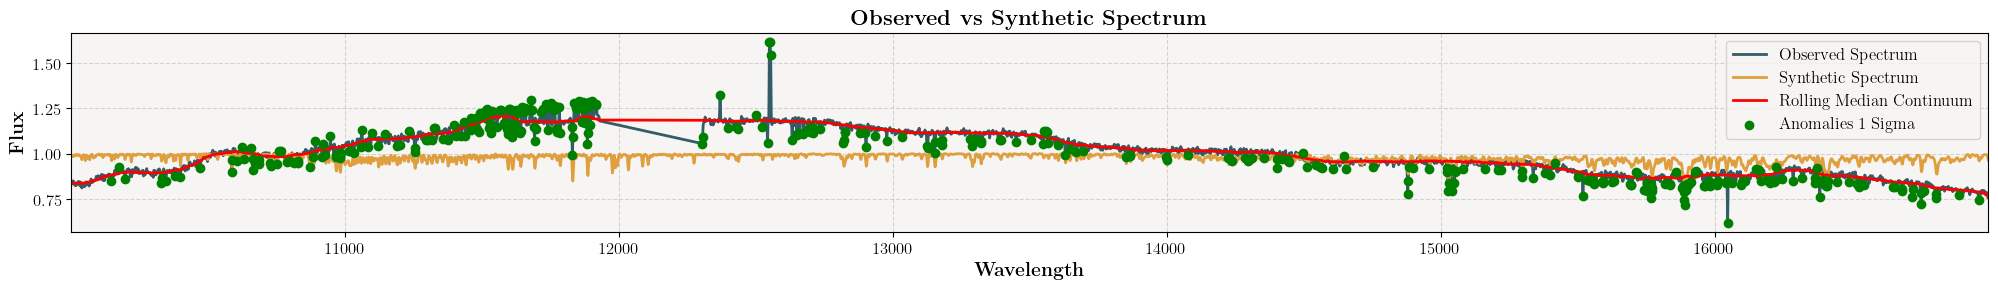

In [117]:
fig, ax = plt.subplots( figsize = (20, 3), sharex=True)

ax.plot(spec49.wavelength, spec49.spectrum, color = cs[0], label='Observed Spectrum')
ax.plot(spec49.synth_wavelength, spec49.synth_spectrum, color = cs[2], label='Synthetic Spectrum')

if spec49.rm is not None:
    ax.plot(spec49.wavelength, spec49.rm, color = 'red', label = 'Rolling Median Continuum', linewidth=2)

ax.scatter(spec49.wavelength[anoms], spec49.spectrum[anoms], color = 'green', label = 'Anomalies 1 Sigma', zorder=9)

ax.set_xlim([min(spec49.wavelength), max(spec49.wavelength)])
ax.set_title(r'\textbf{Observed vs Synthetic Spectrum}')
ax.set_xlabel(r'\textbf{Wavelength}')
ax.set_ylabel(r'\textbf{Flux}')
ax.legend()
plt.tight_layout()
plt.show()